## Lab 02: NumPy, SciPy, and Matplotlib

- **Import before using a package**
- **Point out the short names**

We'll use a short set of temperature readings to work with arrays, make plots, and fit
a line. The readings are provided below; there's no data file to download.

First, import the packages. `import numpy as np` lets us use the short name `np`.
`matplotlib.pyplot` is the plotting module; we'll call it `plt`.

In [3]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

- **Which versions did we import?**

In [4]:
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

NumPy: 1.26.4
SciPy: 1.13.0


### If a package is missing

- **Install into this notebook’s environment**
- **After restarting, import again**

If the import cell gives `ModuleNotFoundError`, the package isn't available in that
kernel. In Colab or your own local notebook, remove the `#` from the line below and run it.
`%pip` installs into the environment used by this notebook.

If installation asks for a restart, restart the kernel. After any successful installation,
rerun the import cell above. Then put the `#` back so Run All doesn't keep running
the installation command. For a different
package, replace the names with the package you need.

On DataHub, these packages should be in the course environment. If they aren't, check
which environment you selected and ask me before installing over the existing setup.
For a separate custom environment, use the [DataHub instructions](https://support.ucsd.edu/services?id=kb_article_view&sysparm_article=KB0033812).

**Install** adds the package to an environment. **Import** makes it available to the
current Python session. You'll import again after a restart. A new Colab runtime may
also need packages installed again.

In [5]:
import art

In [6]:
%pip install art

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### NumPy arrays

- **Same values, different containers**
- **Predict before you run**

With an array, we can apply the same calculation to every number at once. A list behaves
differently: multiplying a list repeats it, while multiplying an array multiplies its values.

In [7]:
values_list = [1, 2, 3]
values_array = np.array(values_list)

- **Predict: a list times two.**

In [8]:
values_list * 2

[1, 2, 3, 1, 2, 3]

- **Same operator. Now an array.**

In [9]:
values_array * 2

array([2, 4, 6])

- **Square every entry.**

In [10]:
values_array**2

array([1, 4, 9])

- **One time, one temperature**
- **Inspect before calculating**

Here's our example data. Each temperature goes with the time at the same index.
`shape` gives the size of each dimension, and `dtype` gives the type of the entries.
These are one-dimensional arrays with six entries each.

In [11]:
time_min = np.array([0, 1, 2, 3, 4, 5], dtype=float)
temperature_c = np.array([20.0, 21.1, 21.8, 23.2, 23.9, 25.1])

- **How many dimensions? How many entries?**

In [12]:
temperature_c.shape

(6,)

- **What kind of numbers are stored?**

In [13]:
temperature_c.dtype

dtype('float64')

- **Convert the whole array at once.**

In [14]:
temperature_c * 9 / 5 + 32

array([68.  , 69.98, 71.24, 73.76, 75.02, 77.18])

In [16]:
def convert2f(ctemp):
    return ctemp * 9 / 5 + 32

In [18]:
convert2f(temperature_c)

array([68.  , 69.98, 71.24, 73.76, 75.02, 77.18])

### Convenience functions
- **Reduce six readings to one mean.**

In [19]:
np.mean(temperature_c)

22.516666666666666

- **Find the smallest and largest readings.**

In [20]:
print("Minimum:", np.min(temperature_c))
print("Maximum:", np.max(temperature_c))

Minimum: 20.0
Maximum: 25.1


- **Remember `0.1 + 0.2`? Compare with tolerance.**

In [21]:
np.isclose(0.1 + 0.2, 0.3)

True

Be careful with `np.isclose` in particular: https://numpy.org/devdocs/reference/generated/numpy.isclose.html

#### Making arrays without typing every value

- **Choose a step or point count**
- **Check whether the endpoint appears**

`np.arange(start, stop, step)` steps through values and excludes the stop value.
`np.linspace(start, stop, num)` makes `num` evenly spaced points, including both endpoints.
Use `linspace` when you want control over the number of points.

In [23]:
np.arange(0, 6, 1)

array([0, 1, 2, 3, 4, 5])

- **Choose the number of points.**

In [24]:
np.linspace(0, 5, 6)

array([0., 1., 2., 3., 4., 5.])

- **More points. Same endpoints.**

In [25]:
np.linspace(0, 5, 11)

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

- **Count the gaps between points**
- **Check the first and last values**

Make an array of 21 evenly spaced points from 0 to 10. What will the spacing be?
Then make the same array using `arange`. Remember that its stop value is excluded.

#### Slices and masks

- **Show the mask before selecting**
- **Keep times and temperatures paired**

Array slices work like list slices. You can also select values with a condition.
`temperature_c > 23` creates an array of `True` and `False` values, called a mask.
Use the same mask on both arrays to keep the times paired with their temperatures.

In [27]:
temperature_c[:3]

array([20. , 21.1, 21.8])

- **One `True` or `False` per reading.**

In [28]:
above_23 = temperature_c > 23
above_23

array([False, False, False,  True,  True,  True])

- **Use the same mask on both arrays.**

In [29]:
print("Selected times:", time_min[above_23])
print("Selected temperatures:", temperature_c[above_23])

Selected times: [3. 4. 5.]
Selected temperatures: [23.2 23.9 25.1]


- **One condition, then two**
- **Parentheses around each comparison**

Change the condition to select readings at or below 23 °C. If you want two conditions,
use `&` with parentheses around each one, for example `(temperature_c > 21) & (temperature_c < 24)`.
Python's `and` doesn't combine array conditions element by element.

#### Make a copy before changing an array

- **Two names. One array.**
- **Change one; check the other**

`new = old` gives the same array a second name. It doesn't copy the data.
A basic slice such as `old[:3]` also shares data with the original array.
Use `.copy()` if you want to change one without changing the other.

In [30]:
original = np.array([10.0, 20.0, 30.0])
same_array = original
same_array[0] = -1
print("Original after changing its other name:", original)

Original after changing its other name: [-1. 20. 30.]


- **Now copy it. Does the original change?**

In [31]:
separate_array = original.copy()
separate_array[0] = 99
print("Original:", original)
print("Copy:", separate_array)

Original: [-1. 20. 30.]
Copy: [99. 20. 30.]


#### Two-dimensional arrays

- **Point to one row and column**
- **Which dimension are we averaging over?**

Suppose we have three runs with four readings each. We'll store one run per row.
An array with shape `(3, 4)` has three rows and four columns. `runs[1, 2]` selects
row 1, column 2.

For this layout, `axis=0` averages across runs, giving one result per time.
`axis=1` averages across times, giving one result per run. Without an axis, `mean`
averages every entry together.

In [32]:
runs = np.array([
    [20.0, 21.0, 22.0, 23.0],
    [20.2, 21.1, 21.9, 23.2],
    [19.8, 20.9, 22.1, 22.8],
])
runs

array([[20. , 21. , 22. , 23. ],
       [20.2, 21.1, 21.9, 23.2],
       [19.8, 20.9, 22.1, 22.8]])

- **Rows first. Columns second.**

In [33]:
runs.shape

(3, 4)

- **Find row 1, column 2.**

In [34]:
runs[1, 2]

21.9

- **Average down the rows. Four results.**

In [35]:
np.mean(runs, axis=0)

array([20., 21., 22., 23.])

- **Average across columns. Three results.**

In [36]:
np.mean(runs, axis=1)

array([21.5, 21.6, 21.4])

- **Predict each result’s length**
- **A colon selects every entry**

Print the first row with `runs[0, :]`, then the first column with `runs[:, 0]`.
The colon selects everything along that dimension. Check their lengths against the shape.

### Matplotlib

- **One marker per pair of values**
- **Label both axes with units**

Let's plot the temperature data. `plt.subplots` returns a figure and an axes object.
The figure is the whole image; the axes is the plot we're drawing on.

`ax.plot(x, y, "o")` draws a marker for each pair of values. Both arrays need the same
length. The labels tell us what the numbers mean and which units we're using.

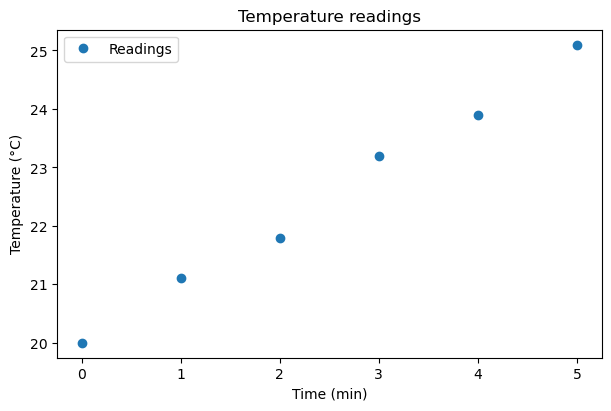

In [42]:
fig_data, ax_data = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax_data.plot(time_min, temperature_c, "o", label="Readings")
ax_data.set_xlabel("Time (min)")
ax_data.set_ylabel("Temperature (°C)")
ax_data.set_title("Temperature readings")
ax_data.legend()
plt.show()

- **Connecting points does not fit them**
- **Two series, same axes**

Change `"o"` to `"o-"` and run the cell again. What changed? The line connects the
points; it doesn't calculate a fit.

Try `color="tab:orange"` in `ax_data.plot(...)`, or change the figure size.
To put two series on the same plot, call `plot` twice on the same axes before `plt.show()`.

#### Plotting a function

- **Pass an array into our function**
- **More x values, more plotted points**

Our functions can accept arrays too, as long as the operations inside work on arrays.
Here's a line, $y=mx+b$. `slope` and `intercept` are inputs, so we can change them when
we call it. A denser grid gives us more points to draw the line with.

In [43]:
def line(x, slope, intercept):
    return slope * x + intercept

- **Choose where to evaluate the function.**

In [44]:
time_dense = np.linspace(0, 5, 101)

- **Draw our guess over the data.**

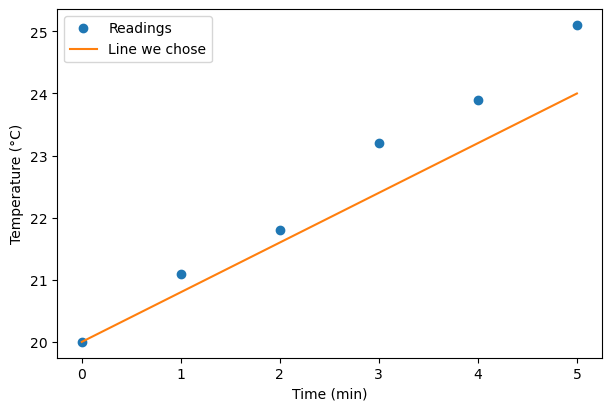

In [45]:
fig_guess, ax_guess = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax_guess.plot(time_min, temperature_c, "o", label="Readings")
ax_guess.plot(time_dense, line(time_dense, 0.8, 20.0), label="Line we chose")
ax_guess.set_xlabel("Time (min)")
ax_guess.set_ylabel("Temperature (°C)")
ax_guess.legend()
plt.show()

- **Change slope, then intercept**
- **Watch what each parameter changes**

In the plotting cell above, change the slope and intercept to get the line closer to the points. Changing the slope
tilts the line; changing the intercept shifts it up or down.

Next we'll have SciPy choose the parameters from the data.

### SciPy

- **Give SciPy the function itself**
- **It chooses the slope and intercept**

SciPy provides routines for tasks such as fitting, integration, and solving equations.
We'll try two of them. `from scipy.optimize import curve_fit` imports one function,
so we can call it as `curve_fit(...)`.

`curve_fit` takes a function, x data, and y data. Here it chooses the slope and intercept
that minimize the sum of squared differences between the line and the readings.
Pass `line`, not `line(...)`: SciPy will call the function with different parameters.

In [46]:
from scipy.optimize import curve_fit

parameters, covariance = curve_fit(line, time_min, temperature_c)

- **Read the slope and intercept.**

In [47]:
fitted_slope, fitted_intercept = parameters
print(f"Slope: {fitted_slope:.3f} °C/min")
print(f"Intercept: {fitted_intercept:.3f} °C")

Slope: 1.009 °C/min
Intercept: 19.995 °C


- **Evaluate the fitted line at our times.**

In [48]:
line(time_min, fitted_slope, fitted_intercept)

array([19.9952381 , 21.00380952, 22.01238095, 23.02095238, 24.02952381,
       25.03809524])

- **Unpack parameters in the function’s order**
- **Residual means data minus fitted value**

`parameters` contains the fitted values in the order they appear after `x` in our function:
slope, then intercept. The assignment to two names unpacks those two values.
`covariance` is a separate estimate of the fitted parameters' covariance; we don't need
it to draw the line.

Plot the result and check the differences. Those differences are called **residuals**.
An axes array lets us put two plots in the same figure.

In [49]:
fitted_values = line(time_min, fitted_slope, fitted_intercept)
residuals = temperature_c - fitted_values
residuals

array([ 0.0047619 ,  0.09619048, -0.21238095,  0.17904762, -0.12952381,
        0.06190476])

- **Plot the fit. Look at the residuals.**

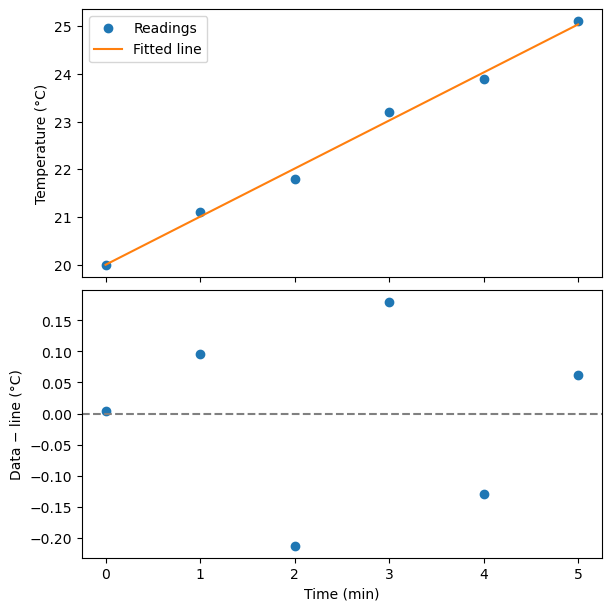

In [50]:
fig_fit, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True, constrained_layout=True)
axes[0].plot(time_min, temperature_c, "o", label="Readings")
axes[0].plot(time_dense, line(time_dense, fitted_slope, fitted_intercept), label="Fitted line")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

axes[1].plot(time_min, residuals, "o")
axes[1].axhline(0, color="0.5", linestyle="--")
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Data − line (°C)")
plt.show()

- **Move one point; predict the fit**
- **Restore the data and rerun**

Increase the last temperature reading by 2 °C in the data cell. Rerun that cell,
the fit, parameter unpacking, residual calculation, and this plot. Does the line move through the changed point, or does it
compromise between all the points? Restore the data when you're done, then rerun the
data, fit, parameter, residual, and plot cells so the figure agrees with the values you'll save.

`sharex=True` makes the two panels use the same x axis limits. `axes[0]` is the top
plot and `axes[1]` is the bottom one.

#### Integrating a function

- **Check against an integral we know**
- **Read both returned values**

`scipy.integrate.quad` calculates a definite integral. For example, the area under
$x^2$ from 0 to 1 is $1/3$. Let's check that numerically.

Give `quad` the function and the two limits. It returns the integral and an estimate
of its numerical error. That estimate doesn't check whether you supplied the right function.

In [51]:
from scipy.integrate import quad

def square(x):
    return x**2

- **Give it the function and two limits.**

In [52]:
area, error_estimate = quad(square, 0, 1)
print("Integral:", area)

Integral: 0.33333333333333337


- **Read the numerical error estimate.**

In [53]:
error_estimate

3.700743415417189e-15

- **Check against a result we know.**

In [54]:
print("Expected:", 1 / 3)
print("Agreement:", np.isclose(area, 1 / 3))

Expected: 0.3333333333333333
Agreement: True


- **Change the limit and expected answer**
- **Use help to check arguments**

Change the upper limit to 2 in the integration cell. Rerun it, then replace both
`1 / 3` values in the check cell with `8 / 3` and run that cell.
Then try another function whose
integral you know. You can look up the arguments with `help(quad)` in a new cell.

### Save a plot and a data file

- **Save the figure and the numbers**
- **Same filename replaces the old file**

`savefig` writes a figure to disk. `np.savetxt` writes numbers, and `np.loadtxt` reads
them back. Here `column_stack` puts the time and temperature arrays into two columns.

These files go into the notebook's current working directory. Running the cell again
replaces the files with these names.

In [55]:
fig_fit.savefig("temperature_fit.png", dpi=150, bbox_inches="tight")

- **One column per variable. Write the CSV.**

In [56]:
table = np.column_stack((time_min, temperature_c))
np.savetxt("temperature.csv", table, delimiter=",",
           header="time_min,temperature_c", comments="")

- **Read the file back.**

In [57]:
loaded = np.loadtxt("temperature.csv", delimiter=",", skiprows=1)
loaded

array([[ 0. , 20. ],
       [ 1. , 21.1],
       [ 2. , 21.8],
       [ 3. , 23.2],
       [ 4. , 23.9],
       [ 5. , 25.1]])

- **Did the numbers survive the round trip?**

In [58]:
np.allclose(loaded, table)

True

- **Load it back; check the columns**
- **Download files before leaving Colab**

`delimiter=","` separates the columns with commas. `skiprows=1` skips the header when
reading the file. `loaded[:, 0]` gives the time column and `loaded[:, 1]` gives temperature.

On DataHub, the files appear in the file browser on the left. Right-click a file to
download it. In Colab, open the Files panel and download them there. Files created in
the Colab runtime aren't automatically saved to Drive and disappear when that runtime is deleted.

### Try it with another dataset

- **Build it from the earlier pieces**
- **Use new names for this dataset**

Use the arrays below to fit and plot a line. Write the code yourself; the earlier cells
have the pieces you need.

1. Print the array shapes and the mean temperature.
2. Plot the readings with axis labels and units.
3. Fit `line` with `curve_fit`, then add the fitted line to your plot.
4. Print the fitted slope and intercept. Save the plot with a new filename.

Keep separate names for this dataset so the earlier plots still use their original data.

In [ ]:
new_time_min = np.array([0, 2, 4, 6, 8], dtype=float)
new_temperature_c = np.array([18.1, 18.9, 20.2, 20.8, 22.1])

In [ ]:
# Add your analysis here.

- **Restart and run everything**
- **Save and download the notebook**

Save your edits, restart the kernel, and run the whole notebook from the top.
In JupyterLab, use **Kernel → Restart Kernel and Run All Cells**. In Colab, restart
the session from **Runtime**, then run all cells.

Fix any missing definitions, save again, and download the `.ipynb`. In Colab, use the
File menu; in JupyterLab, right-click the notebook in the file browser and choose Download.
This gives you a copy with the code, notes, and latest outputs together.

For syntax you don't remember: [NumPy](https://numpy.org/doc/stable/user/absolute_beginners.html),
[Matplotlib](https://matplotlib.org/stable/tutorials/pyplot.html),
[curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html),
[quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html),
and [notebook package installation](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-pip).